# Notebook Análisis de las Series de Tiempo
**CC3084 - Laboratorio 1: Series de Tiempo**

*Rodrigo Ajmac - 22279*

*Andres Mazariegos - 21749*

*June Herrera - 231038*

## 0. Configuración

**Librerías**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

**Dependencias**

In [2]:
data_viajes = '../Datos_Crudos/Base_Migracion_2009-2026jun.xlsx'

**Funciones**

## 1. Procesamiento de Datos

In [3]:
# Leer archivo .xlsx con los datos
df = pd.read_excel(data_viajes)

In [4]:
# Colocar columna de viajero como entero para evitar incongruencias
df['Viajero'] = df['Viajero'].astype(int)

In [5]:
# Agregar columna de fecha
df['fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes cod'].astype(str).str.zfill(2) + '-01'
)

In [6]:
# Verificar que los datos se cargan correctamente
df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1,2009-01-01


### Serie General de Viajeros por Mes

In [7]:
# Agrupar total viajeros de cada mes 
df_general = df.groupby(['fecha'])['Viajero'].sum()

In [8]:
df_general.head()

fecha
2009-01-01    183454
2009-02-01    149376
2009-03-01    174177
2009-04-01    182787
2009-05-01    133129
Name: Viajero, dtype: int64

### Top 3 Países con Más Viajeros

In [9]:
top5_paises = (
    df.groupby('País')['Viajero']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top5_paises)

País
El Salvador                  16212162
Guatemala                    14790279
Estados Unidos de América     7046014
Honduras                      2786735
México                        1807111
Name: Viajero, dtype: int64


#### Serie para El Salvador

In [10]:
df_salvador = df[df['País']=='El Salvador']
df_salvador_copy = df_salvador
df_salvador = df_salvador.groupby(['fecha'])['Viajero'].sum()

In [11]:
df_salvador.head()

fecha
2009-01-01    31602
2009-02-01    26605
2009-03-01    34544
2009-04-01    35522
2009-05-01    27166
Name: Viajero, dtype: int64

#### Serie para Guatemala 

In [12]:
df_gtm = df[df['País']=='Guatemala']
df_gtm_copy = df_gtm
df_gtm = df_gtm.groupby(['fecha'])['Viajero'].sum()

In [13]:
df_gtm.head()

fecha
2009-01-01    57038
2009-02-01    40948
2009-03-01    49410
2009-04-01    58288
2009-05-01    44286
Name: Viajero, dtype: int64

#### Serie para USA

In [14]:
df_usa = df[df['País']=='Estados Unidos de América']
df_usa_copy = df_usa
df_usa = df_usa.groupby(['fecha'])['Viajero'].sum()

In [15]:
df_usa.head()

fecha
2009-01-01    24269
2009-02-01    24057
2009-03-01    30692
2009-04-01    26831
2009-05-01    22029
Name: Viajero, dtype: int64

### Vías de Llegada al País

#### Vía Aérea

In [16]:
df_aerea = df[df['Vía']=='Aérea']
df_aerea_copy = df_aerea.copy()
df_aerea = df_aerea.groupby(['fecha'])['Viajero'].sum()

In [17]:
df_aerea.head()

fecha
2009-01-01    81693
2009-02-01    70099
2009-03-01    84494
2009-04-01    80618
2009-05-01    64621
Name: Viajero, dtype: int64

#### Vía Terrestre

In [18]:
df_terrestre = df[df['Vía']=='Terrestre']
df_terrestre_copy = df_terrestre.copy()
df_terrestre = df_terrestre.groupby(['fecha'])['Viajero'].sum()

In [19]:
df_terrestre.head()

fecha
2009-01-01    88383
2009-02-01    67604
2009-03-01    78162
2009-04-01    92880
2009-05-01    61992
Name: Viajero, dtype: int64

#### Vía Marítima

In [20]:
df_maritima = df[df['Vía']=='Marítima']
df_maritima_copy = df_maritima.copy()
df_maritima = df_maritima.groupby(['fecha'])['Viajero'].sum()

In [21]:
df_maritima.head()

fecha
2009-01-01    13378
2009-02-01    11673
2009-03-01    11521
2009-04-01     9289
2009-05-01     6516
Name: Viajero, dtype: int64

## 2. Gráficos y Compenetes de las Series

### Serie General de Viajeros por Mes

<Axes: title={'center': 'Cantidad de viajeros por mes'}, xlabel='fecha'>

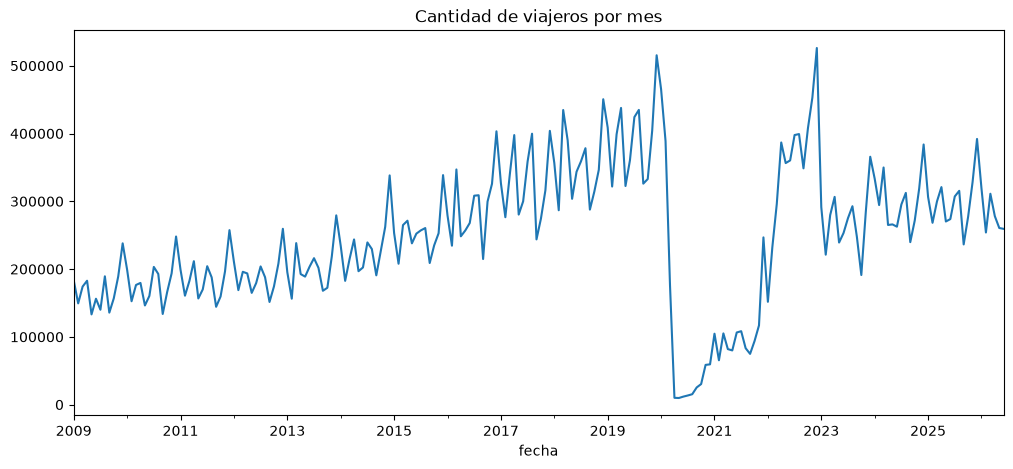

In [22]:
df_general.plot(figsize=(12, 5), title='Cantidad de viajeros por mes')

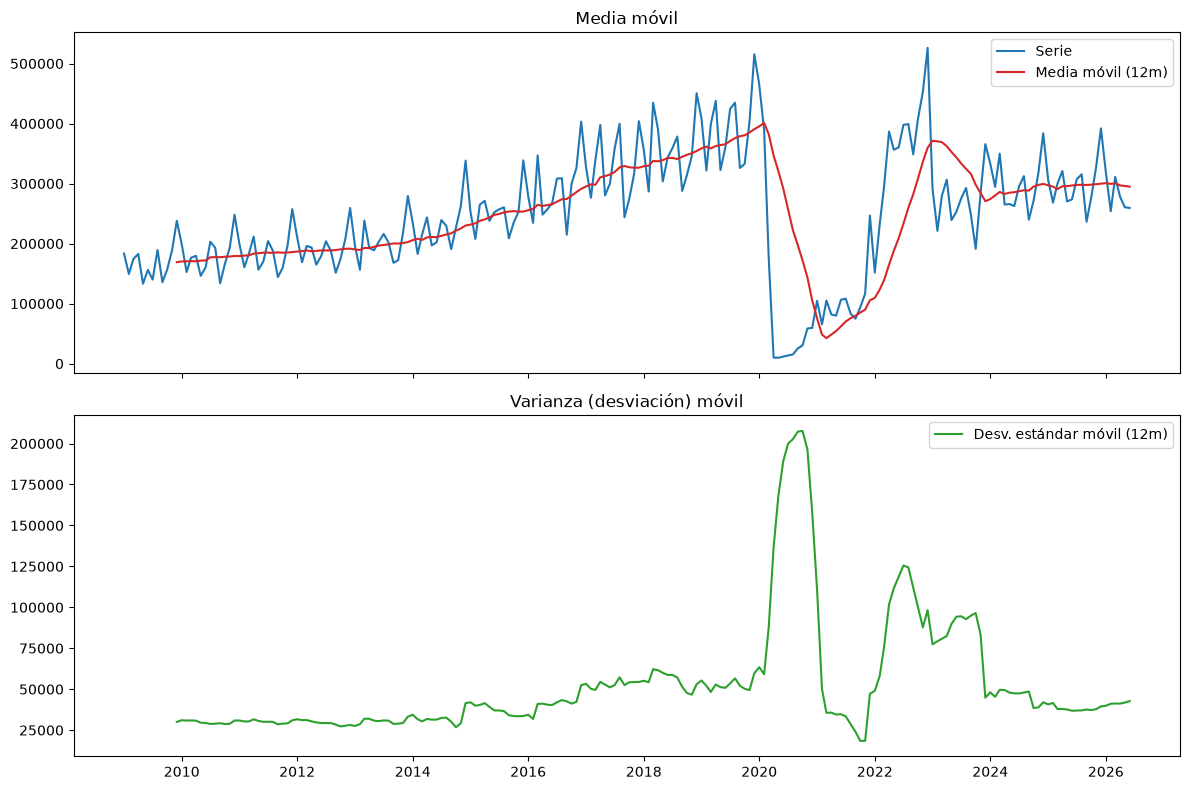

In [23]:
ventana = 12
media_movil = df_general.rolling(ventana).mean()
std_movil = df_general.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_general, label="Serie", color="#1f77b4")
ax[0].plot(media_movil, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil"); ax[0].legend()

ax[1].plot(std_movil, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil"); ax[1].legend()
plt.tight_layout(); plt.show()

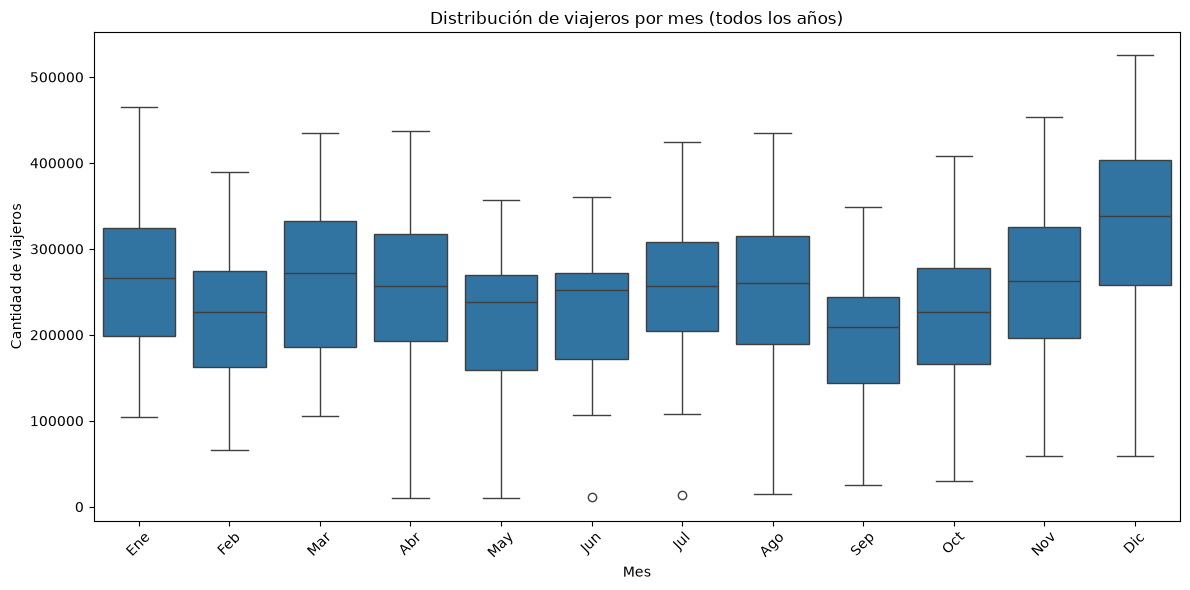

In [24]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (todos los años)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

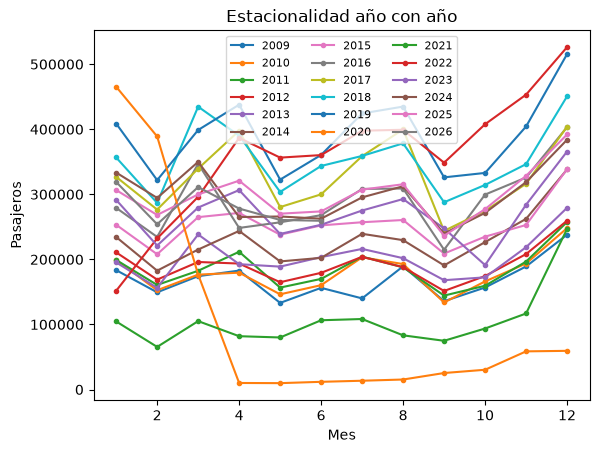

In [25]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

A partir de las gráficas podemos determinar que la serie presento un evento característico. Podemos observar como desde el año 2010 hasta principios del año 2020 presenta una tendencia creciente sin embargo, durante esos primeros meses hay una caída en la cantidad de viajeros arrivando a Guatemala, esto se puede explicar a partir de la pandemia de COVID 19 que afectó a todo el mundo y limitó (incluso completamente) los viajes internacionales. Posterior a ello desde finales del año 2020 y hasta finales del año 2022 la tendencia de viajeros llegando a Guatemala fue creciente, e incluso mayor que el período anterior a dicho evento. A partir del año 2023 la cantidad de viajeros sigue una tendencia creciente aunque con un ritmo menos pronunciado que el de la ventana finales 2020 a finales del 2022. Asimismo, parece que la serie presenta estacionalidad alcanzando sus valores máximos en los meses de marzo/abril, agosto y diciembre, esto se podría explicar por los turistas atraidos por las actividades culturales únicas del país que se realizan durante la semana santa (meses marzo/abril), las vacaciones de verano en diversos países del mundo (mes de agosto) y las vacaciones de fin de año (mes de diciembre). 

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 

### Series para Top 3 Países con más Viajeros

#### Serie para Viajeros de El Salvador (Top 1)

<Axes: title={'center': 'Cantidad de viajeros por mes (Originarios de El Salvador)'}, xlabel='fecha'>

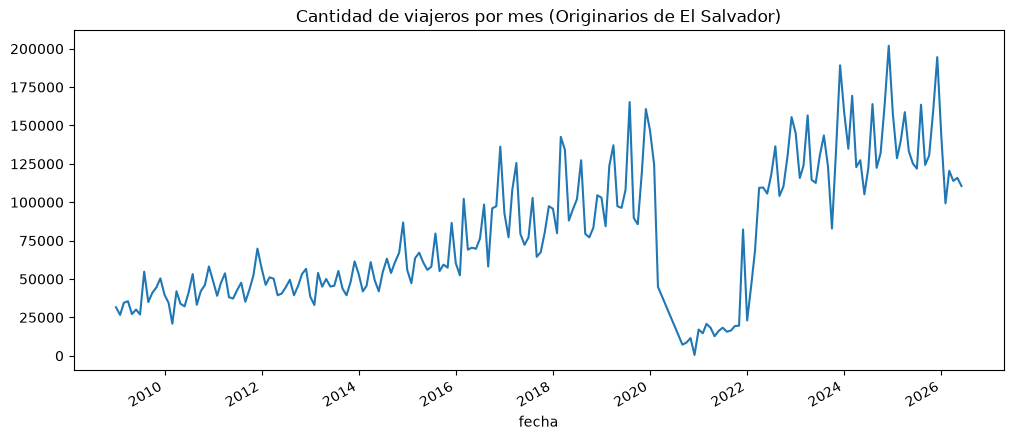

In [26]:
df_salvador.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Originarios de El Salvador)')

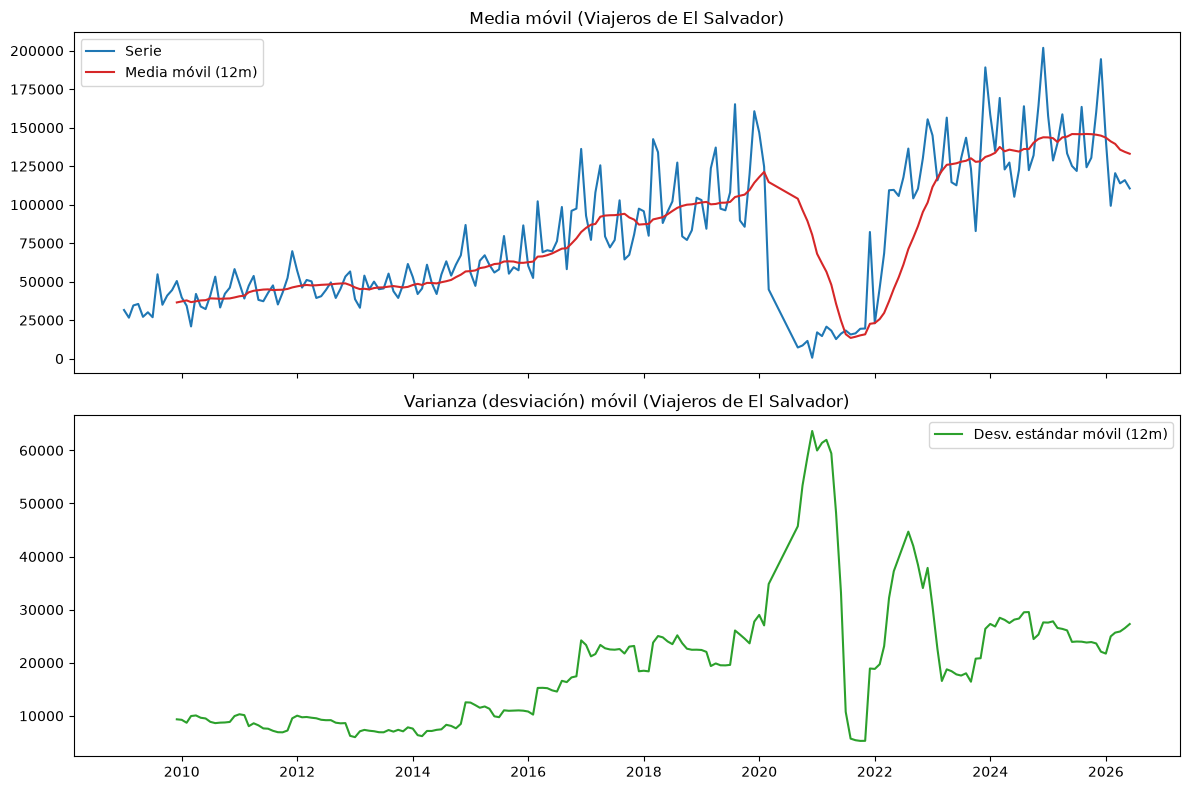

In [27]:
media_movil_slv = df_salvador.rolling(ventana).mean()
std_movil_slv = df_salvador.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_salvador, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_slv, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Viajeros de El Salvador)"); ax[0].legend()

ax[1].plot(std_movil_slv, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Viajeros de El Salvador)"); ax[1].legend()
plt.tight_layout(); plt.show()

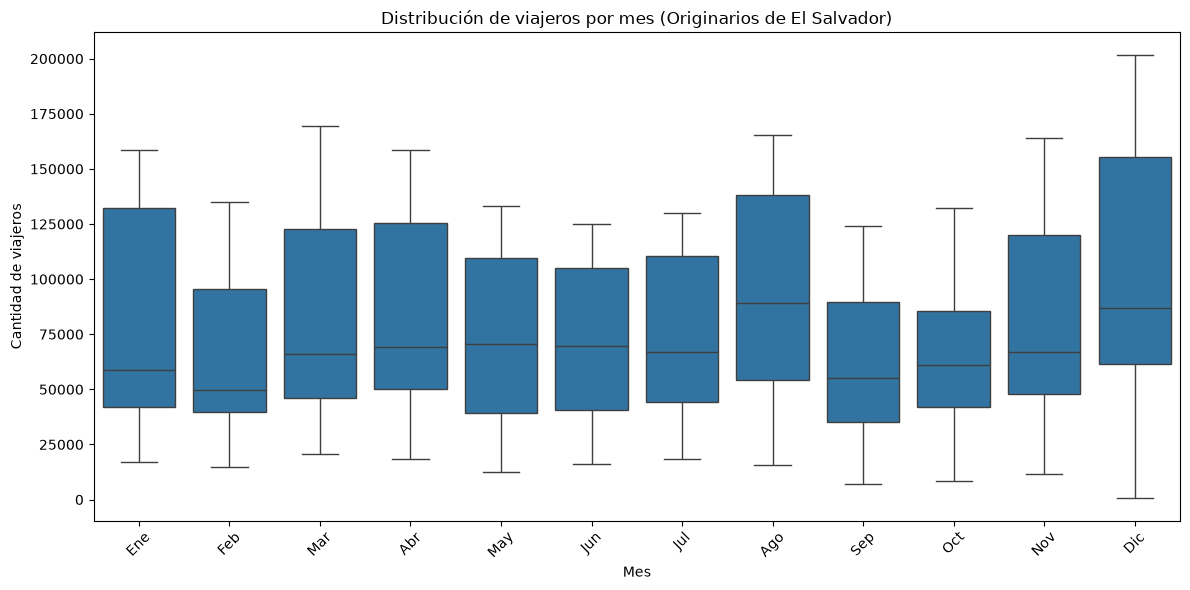

In [28]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_salvador_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Originarios de El Salvador)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

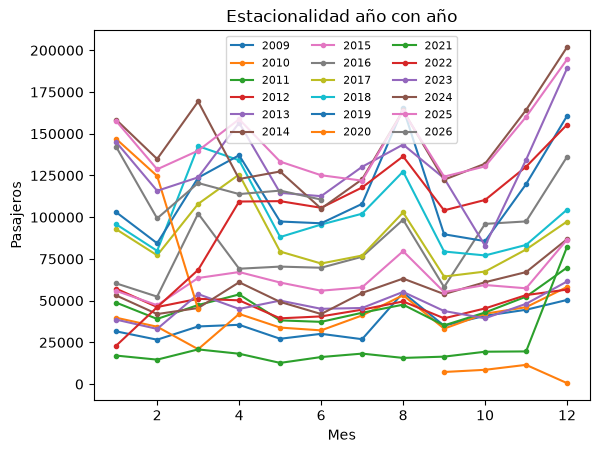

In [29]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_salvador_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

El análisis de esta serie es bastante parecido al realizado anteriormente para la serie general. A partir de las gráficas podemos determinar que la serie presento un evento característico. Podemos observar como desde el año 2010 hasta principios del año 2020 presenta una tendencia creciente sin embargo, durante esos primeros meses hay una caída en la cantidad de viajeros arrivando a Guatemala, esto se puede explicar a partir de la pandemia de COVID 19 que afectó a todo el mundo y limitó (incluso completamente) los viajes internacionales. Posterior a ello desde finales del año 2020 y hasta finales del año 2022 la tendencia de viajeros llegando a Guatemala fue creciente, e incluso mayor que el período anterior a dicho evento. A partir del año 2023 la cantidad de viajeros sigue una tendencia creciente aunque con un ritmo menos pronunciado que el de la ventana finales 2020 a finales del 2022. Asimismo, parece que la serie presenta estacionalidad alcanzando sus valores máximos en los meses de marzo/abril, agosto y diciembre, esto se podría explicar por los turistas atraidos por las actividades culturales únicas del país que se realizan durante la semana santa (meses marzo/abril), las vacaciones de verano en diversos países del mundo (mes de agosto) y las vacaciones de fin de año (mes de diciembre). La única diferencia a destacar es que en los últimos meses la tendencia de visitantes de este país parece ir en disminución, por lo que es algo a tomar en cuenta al momento de modelar la serie. 

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 

#### Serie para Viajeros de Guatemala (Top 2)

<Axes: title={'center': 'Cantidad de viajeros por mes (Originarios de Guatemala)'}, xlabel='fecha'>

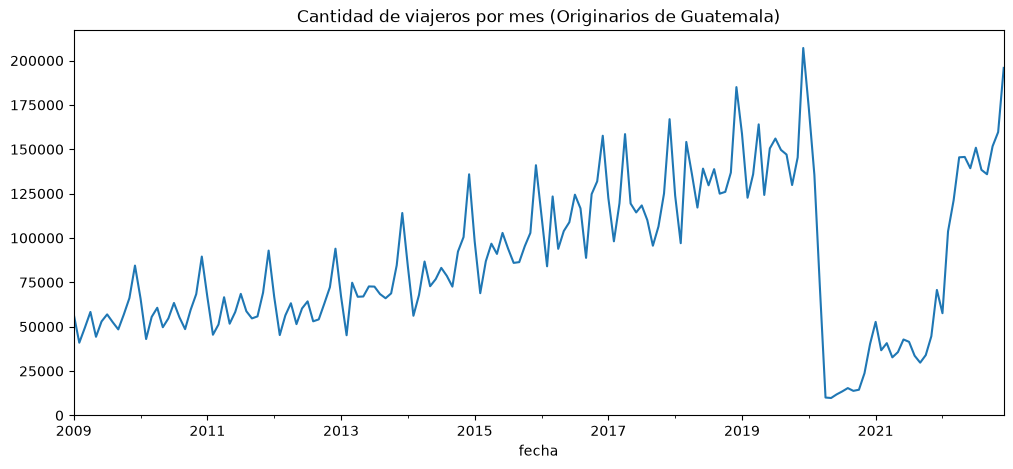

In [30]:
df_gtm.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Originarios de Guatemala)')

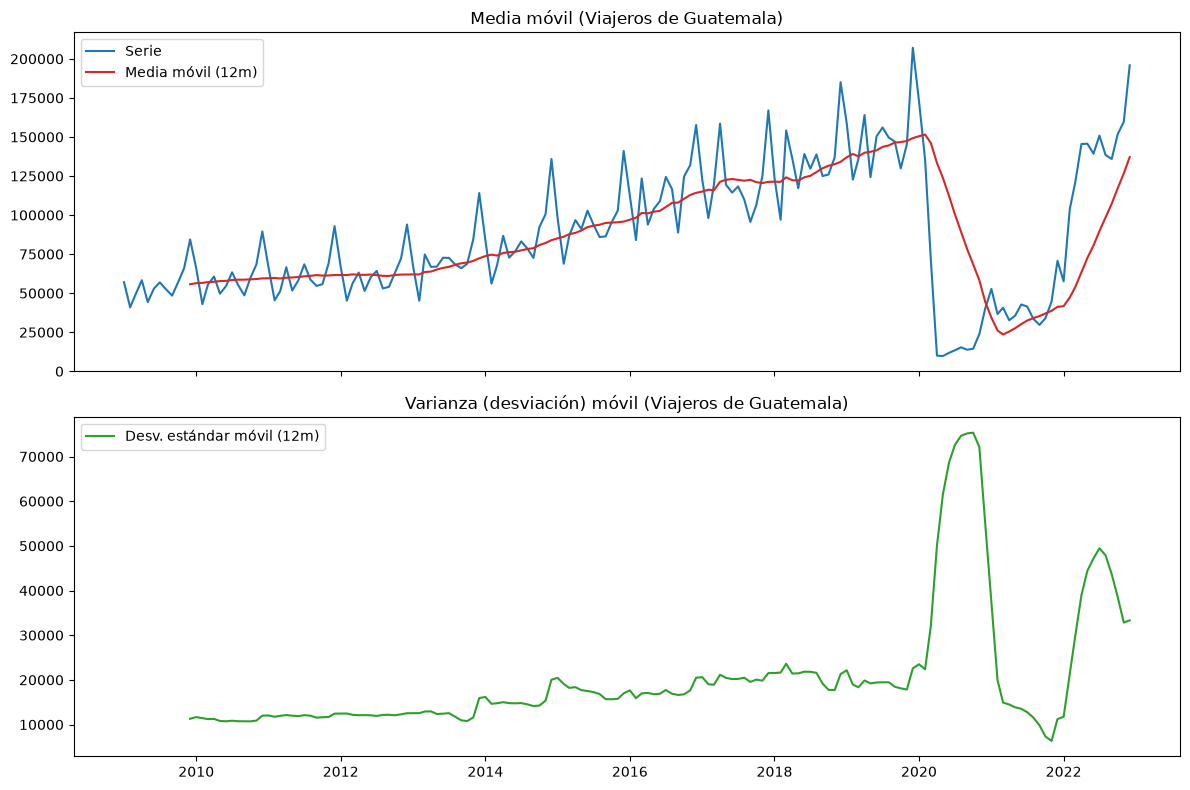

In [31]:
media_movil_gtm = df_gtm.rolling(ventana).mean()
std_movil_gtm = df_gtm.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_gtm, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_gtm, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Viajeros de Guatemala)"); ax[0].legend()

ax[1].plot(std_movil_gtm, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Viajeros de Guatemala)"); ax[1].legend()
plt.tight_layout(); plt.show()

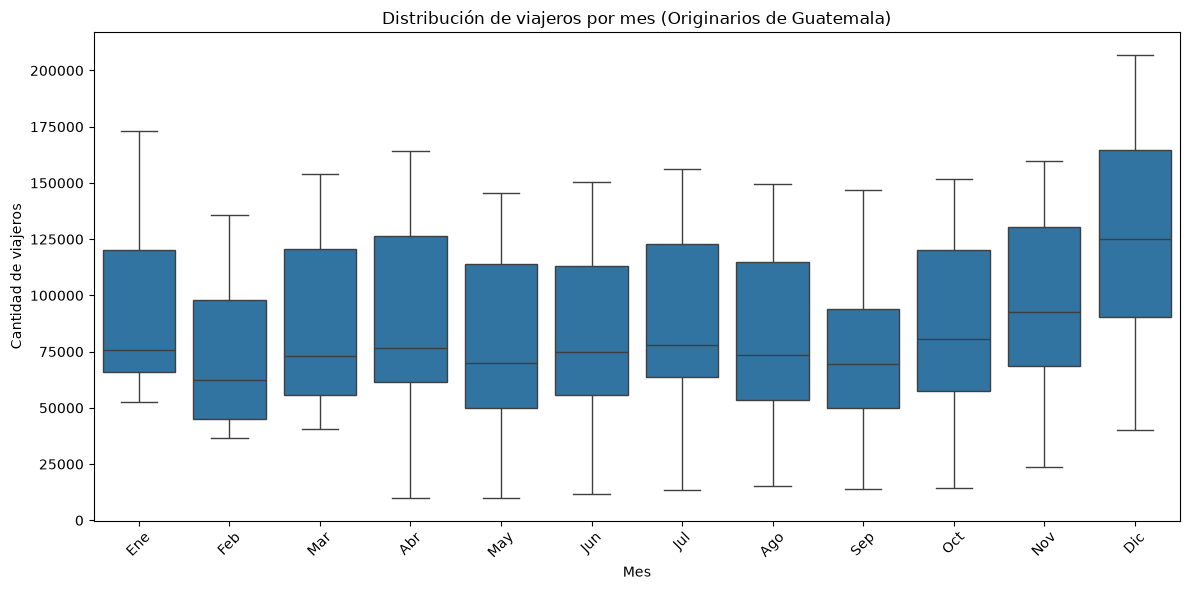

In [32]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_gtm_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Originarios de Guatemala)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

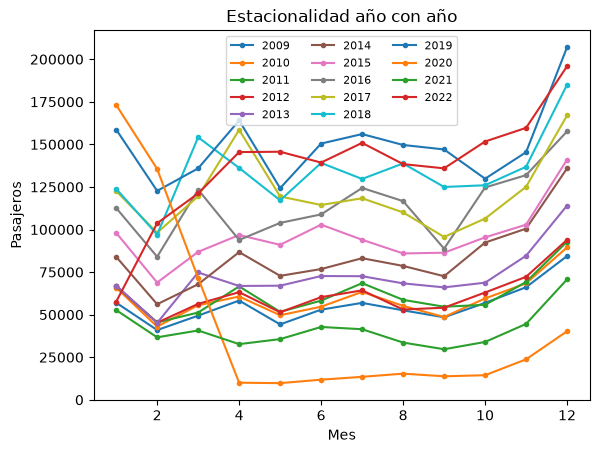

In [33]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_gtm_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

El análisis de esta serie es bastante parecido al realizado anteriormente para la serie general. A partir de las gráficas podemos determinar que la serie presento un evento característico. Podemos observar como desde el año 2010 hasta principios del año 2020 presenta una tendencia creciente sin embargo, durante esos primeros meses hay una caída en la cantidad de viajeros arrivando a Guatemala, esto se puede explicar a partir de la pandemia de COVID 19 que afectó a todo el mundo y limitó (incluso completamente) los viajes internacionales. Asimismo, parece que la serie presenta estacionalidad alcanzando sus valor máximo diciembre, esto se podría explicar por los turistas atraidos por las  vacaciones de fin de año (mes de diciembre), en donde guatemaltecos pueden regresar al país a visitar a sus familiares. La única diferencia de viajeros de El Salvador, es que en los últimos meses la tendencia de visitantes de este país parece ir en aumento y posee una estacionalidad más marcada, por lo que es algo a tomar en cuenta al momento de modelar la serie. 

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 

#### Serie para Viajeros de USA (Top 3)

<Axes: title={'center': 'Cantidad de viajeros por mes (Originarios de USA)'}, xlabel='fecha'>

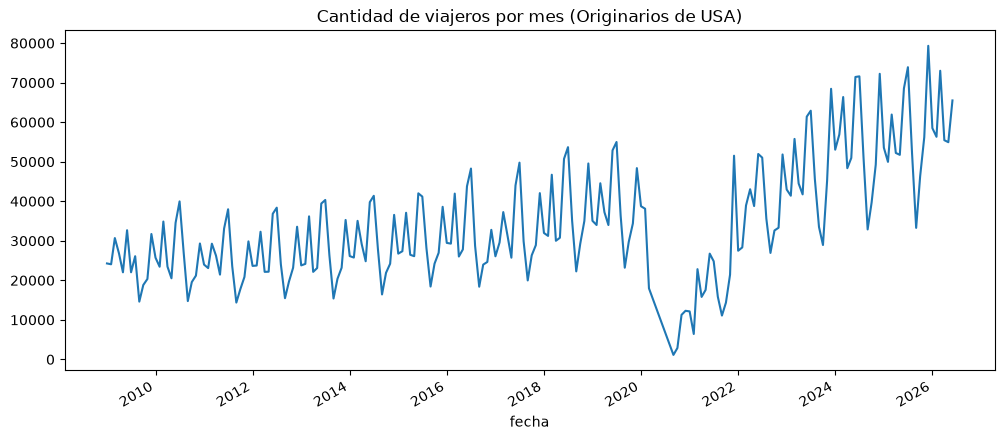

In [34]:
df_usa.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Originarios de USA)')

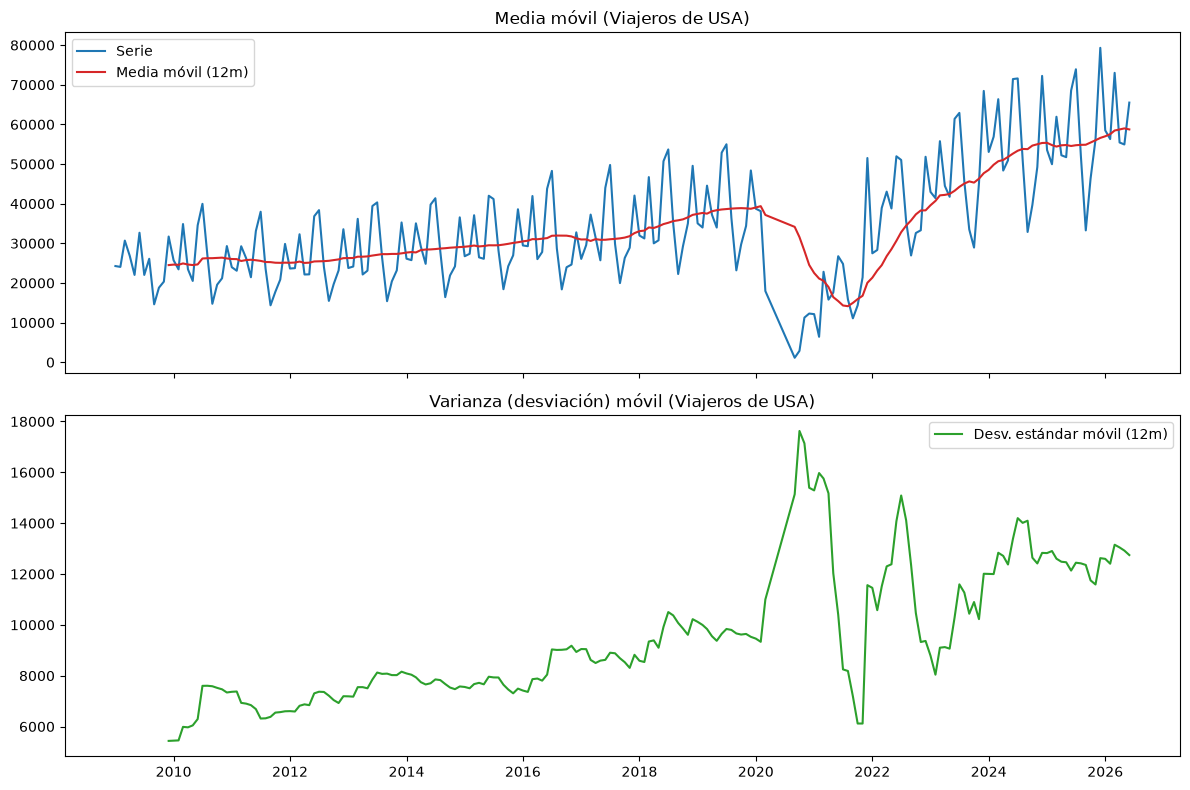

In [35]:
media_movil_usa = df_usa.rolling(ventana).mean()
std_movil_usa = df_usa.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_usa, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_usa, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Viajeros de USA)"); ax[0].legend()

ax[1].plot(std_movil_usa, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Viajeros de USA)"); ax[1].legend()
plt.tight_layout(); plt.show()

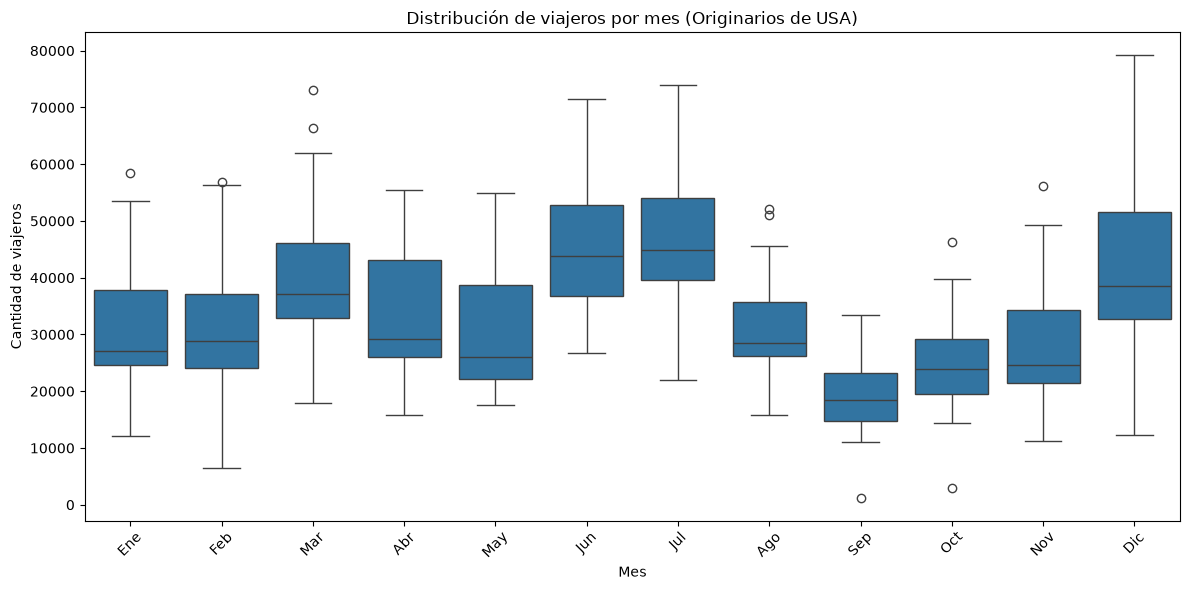

In [36]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_usa_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Originarios de USA)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

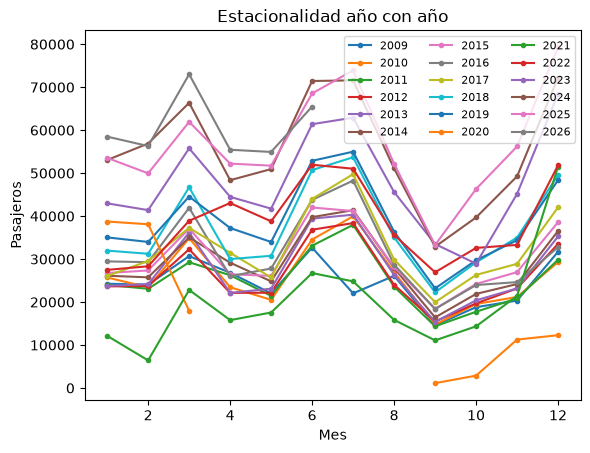

In [37]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_usa_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

El análisis de esta serie es bastante parecido al realizado anteriormente para la serie general. A partir de las gráficas podemos determinar que la serie presento un evento característico. Podemos observar como desde el año 2010 hasta principios del año 2020 presenta una tendencia creciente sin embargo, durante esos primeros meses hay una caída en la cantidad de viajeros arrivando a Guatemala, esto se puede explicar a partir de la pandemia de COVID 19 que afectó a todo el mundo y limitó (incluso completamente) los viajes internacionales. Asimismo, parece que la serie presenta estacionalidad alcanzando sus valores máximos en los meses de marzo/abril, agosto y diciembre, esto se podría explicar por las vacaciones de verano en USA (meses de junio, julio, agosto) y las vacaciones de fin de año (mes de diciembre). La única diferencia de viajeros de El Salvador, es que en los últimos meses la tendencia de visitantes de este país parece ir en aumento y muestra una estacionalidad más marcada a diferencia de El Salvador, por lo que es algo a tomar en cuenta al momento de modelar la serie. 

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 

### Series para Vías de Arrivo

#### Vía Aérea

<Axes: title={'center': 'Cantidad de viajeros por mes (Vía Aérea)'}, xlabel='fecha'>

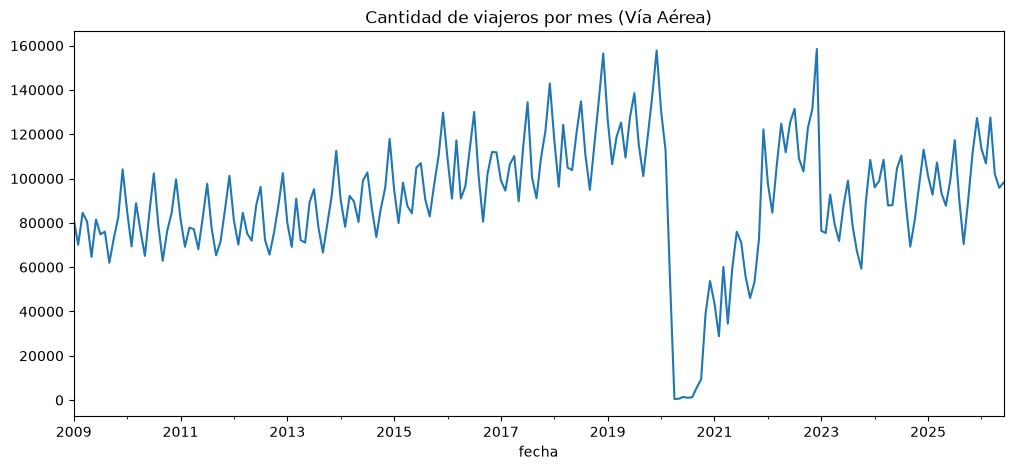

In [38]:
df_aerea.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Vía Aérea)')

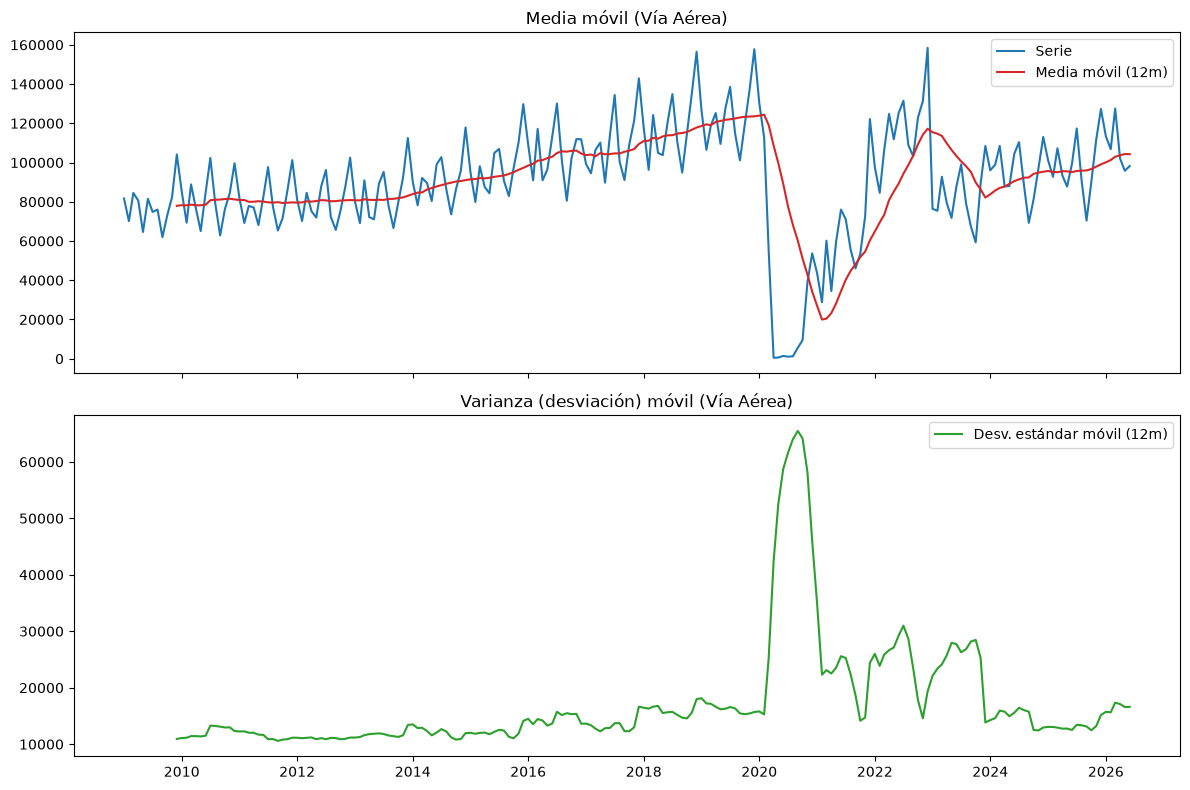

In [39]:
media_movil_aerea = df_aerea.rolling(ventana).mean()
std_movil_aerea = df_aerea.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_aerea, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_aerea, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Vía Aérea)"); ax[0].legend()

ax[1].plot(std_movil_aerea, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Vía Aérea)"); ax[1].legend()
plt.tight_layout(); plt.show()

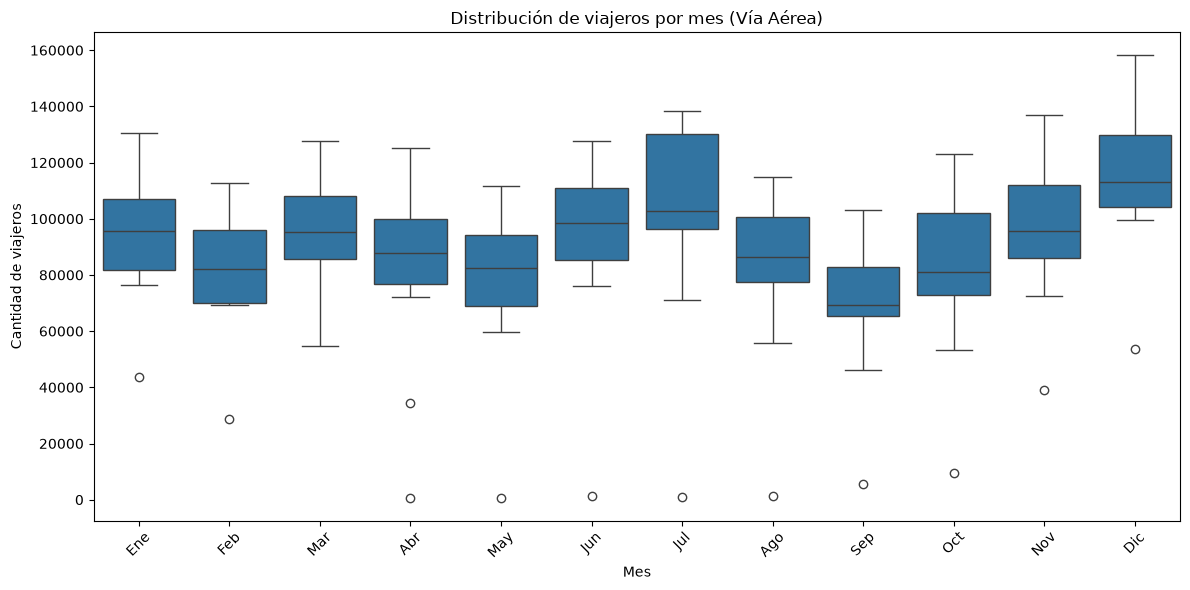

In [40]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_aerea_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Vía Aérea)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

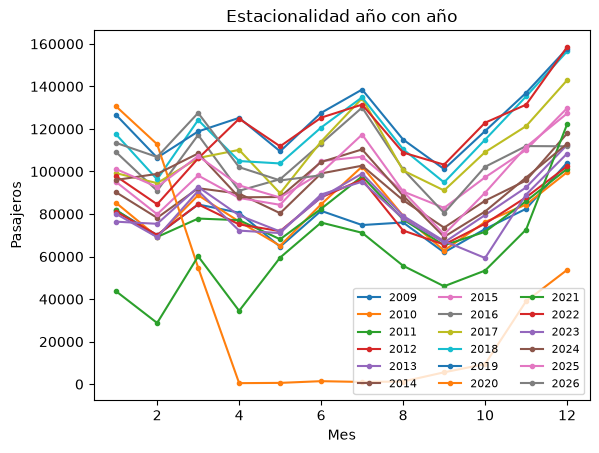

In [41]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_aerea_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

El análisis de esta serie muestra una tendencia creciente con un claro decrecimiento en el año 2020 a consecuencia de la pandemia. Además muestra estacionalidad en los meses de marzo, abril, julio y diciembre que representan las temporadas altas de viaje hacía el país.  

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 

#### Vía Terrestre

<Axes: title={'center': 'Cantidad de viajeros por mes (Vía Terrestre)'}, xlabel='fecha'>

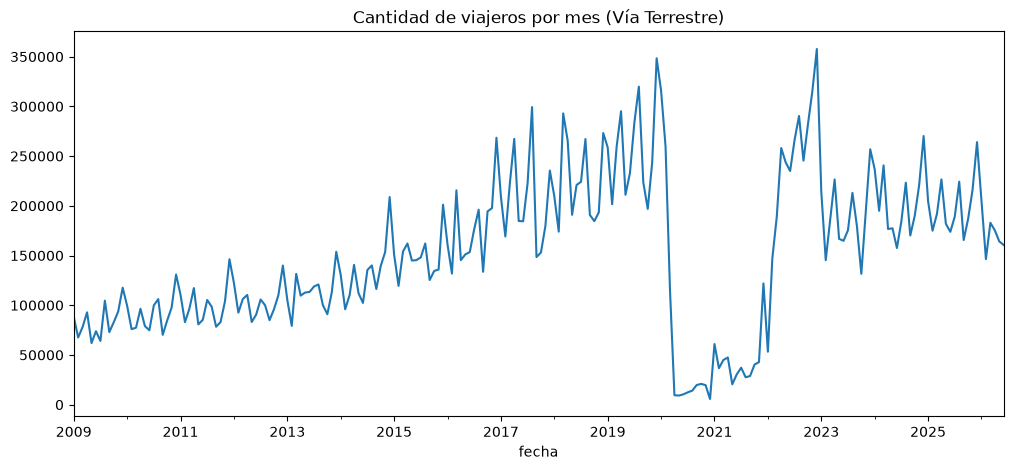

In [42]:
df_terrestre.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Vía Terrestre)')

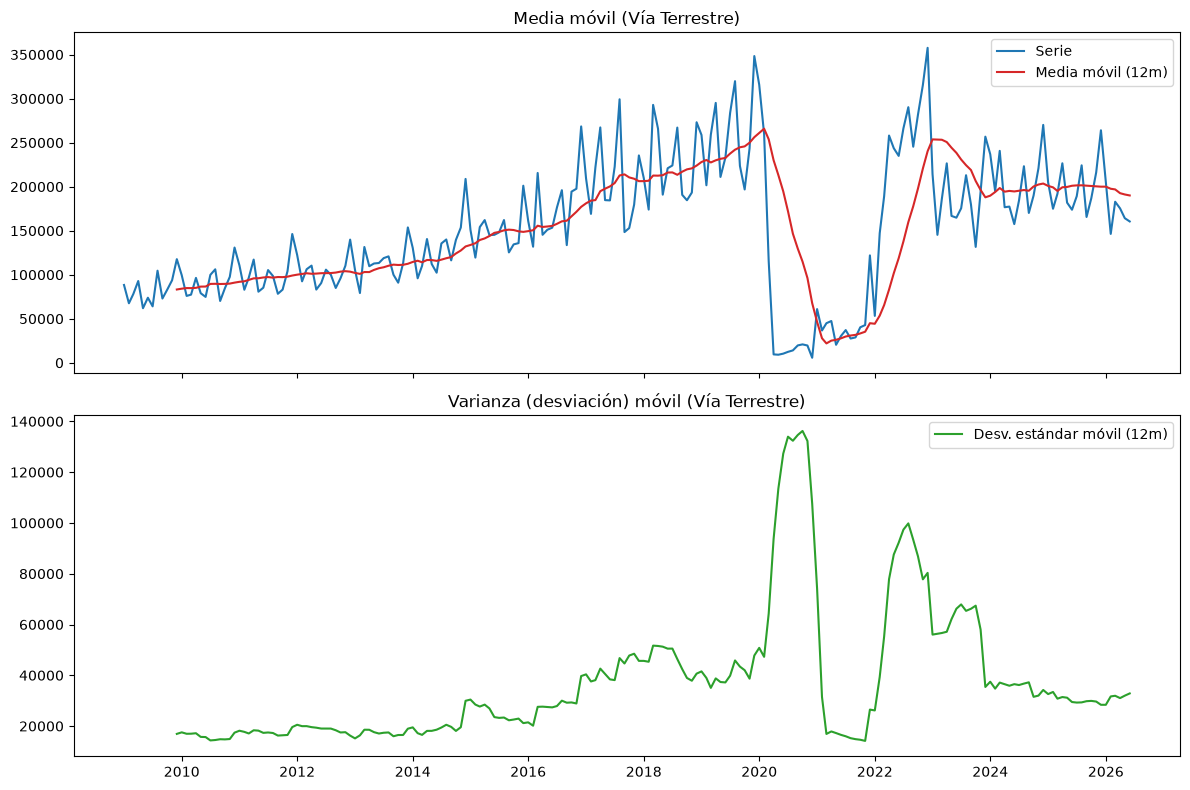

In [43]:
media_movil_terrestre = df_terrestre.rolling(ventana).mean()
std_movil_terrestre = df_terrestre.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_terrestre, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_terrestre, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Vía Terrestre)"); ax[0].legend()

ax[1].plot(std_movil_terrestre, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Vía Terrestre)"); ax[1].legend()
plt.tight_layout(); plt.show()

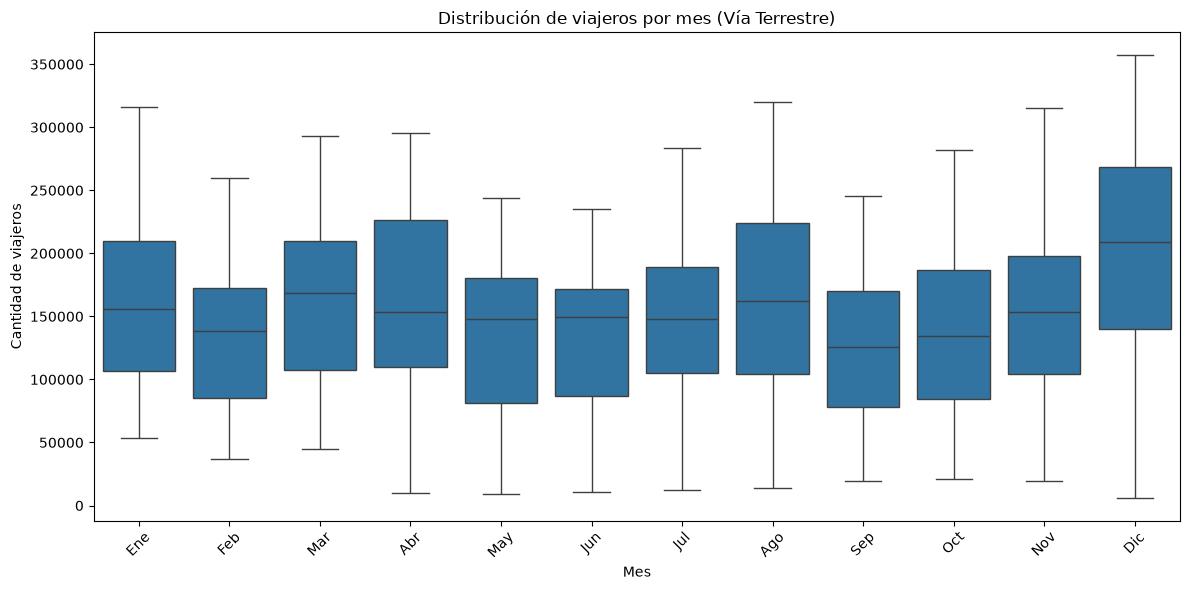

In [44]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_terrestre_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Vía Terrestre)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

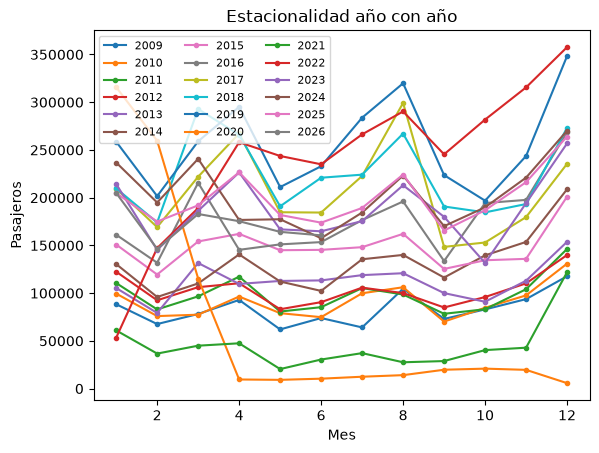

In [45]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_terrestre_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

El análisis de esta serie muestra una tendencia creciente con un claro decrecimiento en el año 2020 a consecuencia de la pandemia. Además muestra estacionalidad en los meses de abril, agosto y diciembre que representan las temporadas altas de viaje hacía el país y tomando en cuenta que el ingreso se da de forma terrestre concuerda con las celebración y tradiciones de la Semana Santa en el país, así como el buen clima para viajar lo que muestra como la gente de países aledaños se sienten atraídos por estas actividades, así como el fin de año que es una temporada alta atrae más viajeros al país.  

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 

#### Vía Marítima

<Axes: title={'center': 'Cantidad de viajeros por mes (Vía Marítima)'}, xlabel='fecha'>

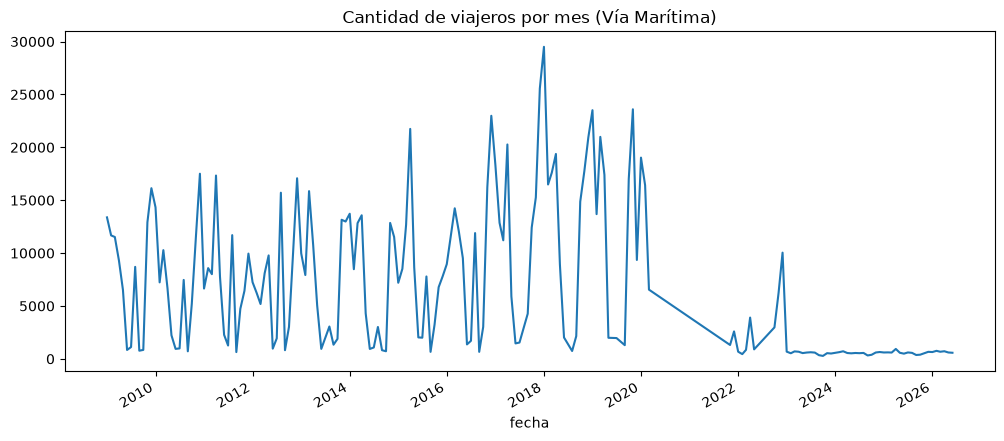

In [46]:
df_maritima.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Vía Marítima)')

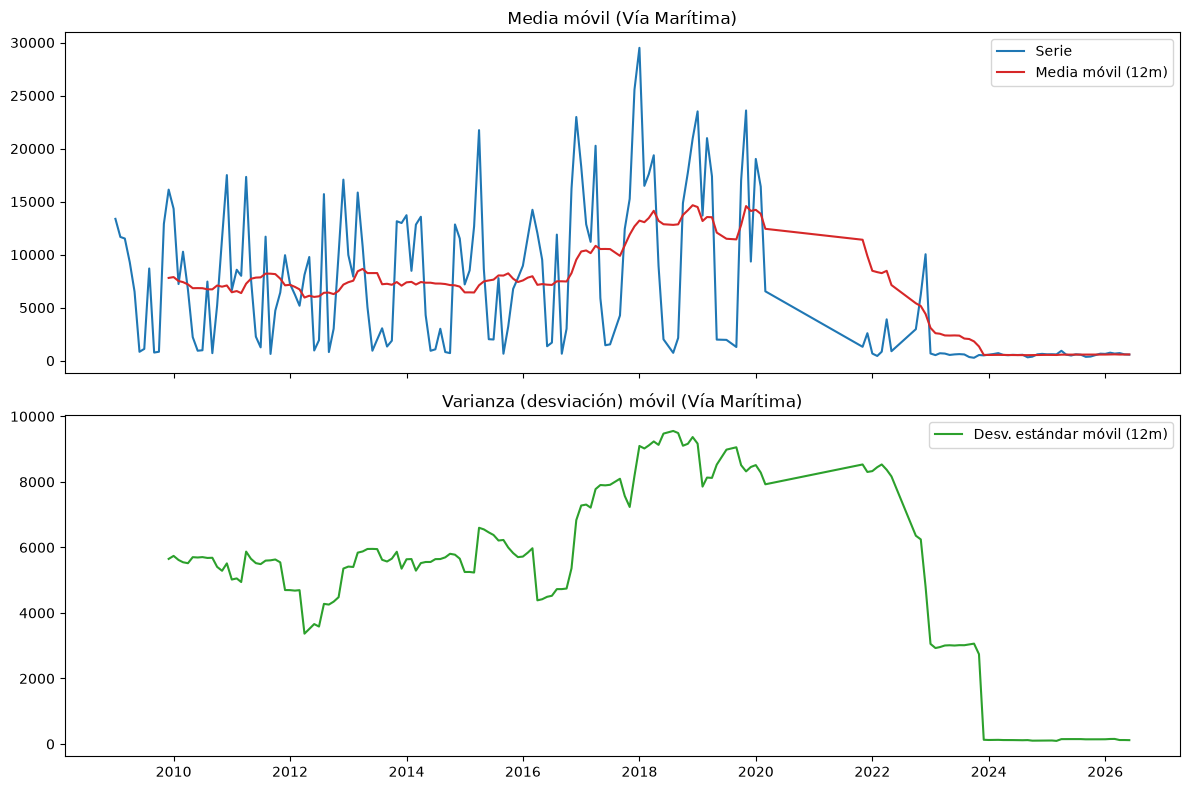

In [47]:
media_movil_maritima = df_maritima.rolling(ventana).mean()
std_movil_maritima = df_maritima.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_maritima, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_maritima, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Vía Marítima)"); ax[0].legend()

ax[1].plot(std_movil_maritima, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Vía Marítima)"); ax[1].legend()
plt.tight_layout(); plt.show()

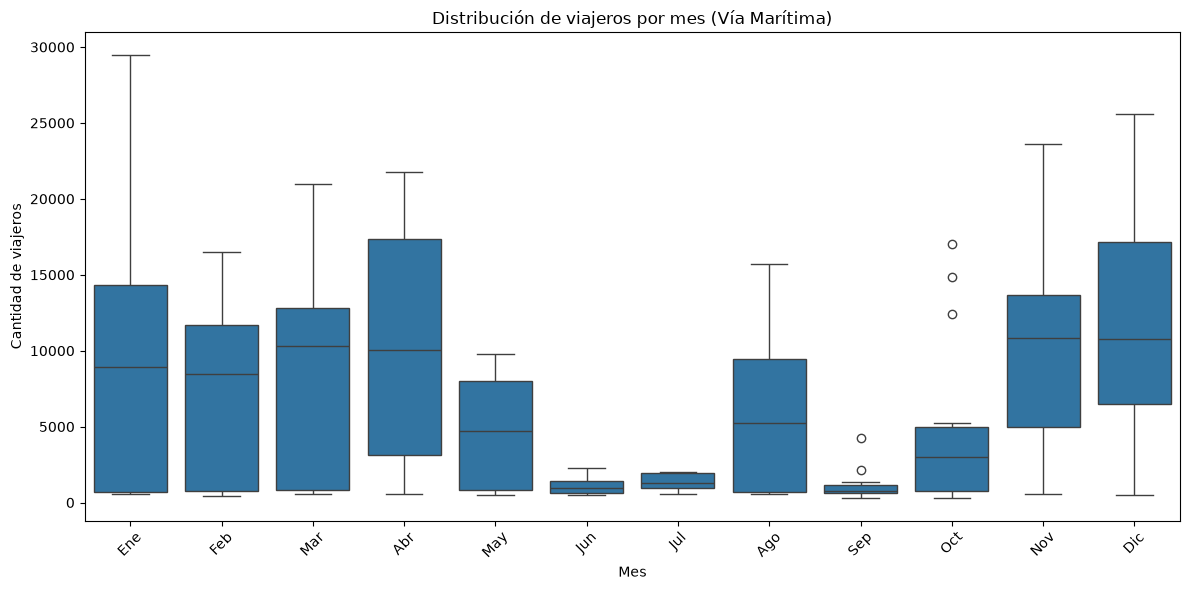

In [48]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_maritima_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Vía Marítima)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

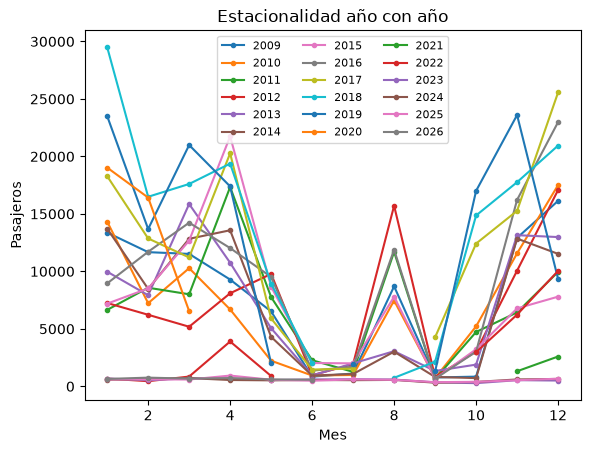

In [49]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_maritima_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

Esta serie parece ser la más compleja debido a las características que posee. Podemos ver que hasta el año 2023 mantenía una tendencia creciente moderada (exceptuando los años de la pandemia del COVID 19), pero luego de esta período los ingresos por vía marítima se caen completamente por lo que podríamos considerar que esta serie tiene bastante ruido ya que no presenta un patrón similar si se comparan ambas ventanas de tiempo. Además posee características como tendencia y estacionalida.

Dado a que la serie parece presentar las características mencionadas anteriormente (tendencia y estacionalidad), es muy probable que no cumpla los supuestos de estacionariedad, por lo que un modelo clásico (AR, MA, ARMA o ARIMA) puede no resultar útil en un inicio, por lo que se recomienda implementar alguna transformación o diferenciación para volverla estacionaria y poder implementar uno de los siguientes modelos, de lo contrario proceder con un modelo más complejo como un SARIMA, SARIMAX o NN. 
